In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [15]:
import matplotlib as mpl
mpl.rcParams["figure.figsize"] = (10, 6)   # default size for all plots
mpl.rcParams["figure.dpi"] = 80            # lower inline resolution

In [16]:
master = pd.read_csv("../data/processed/quarterly_master.csv", parse_dates=["date"])

# Plotting Level Variables

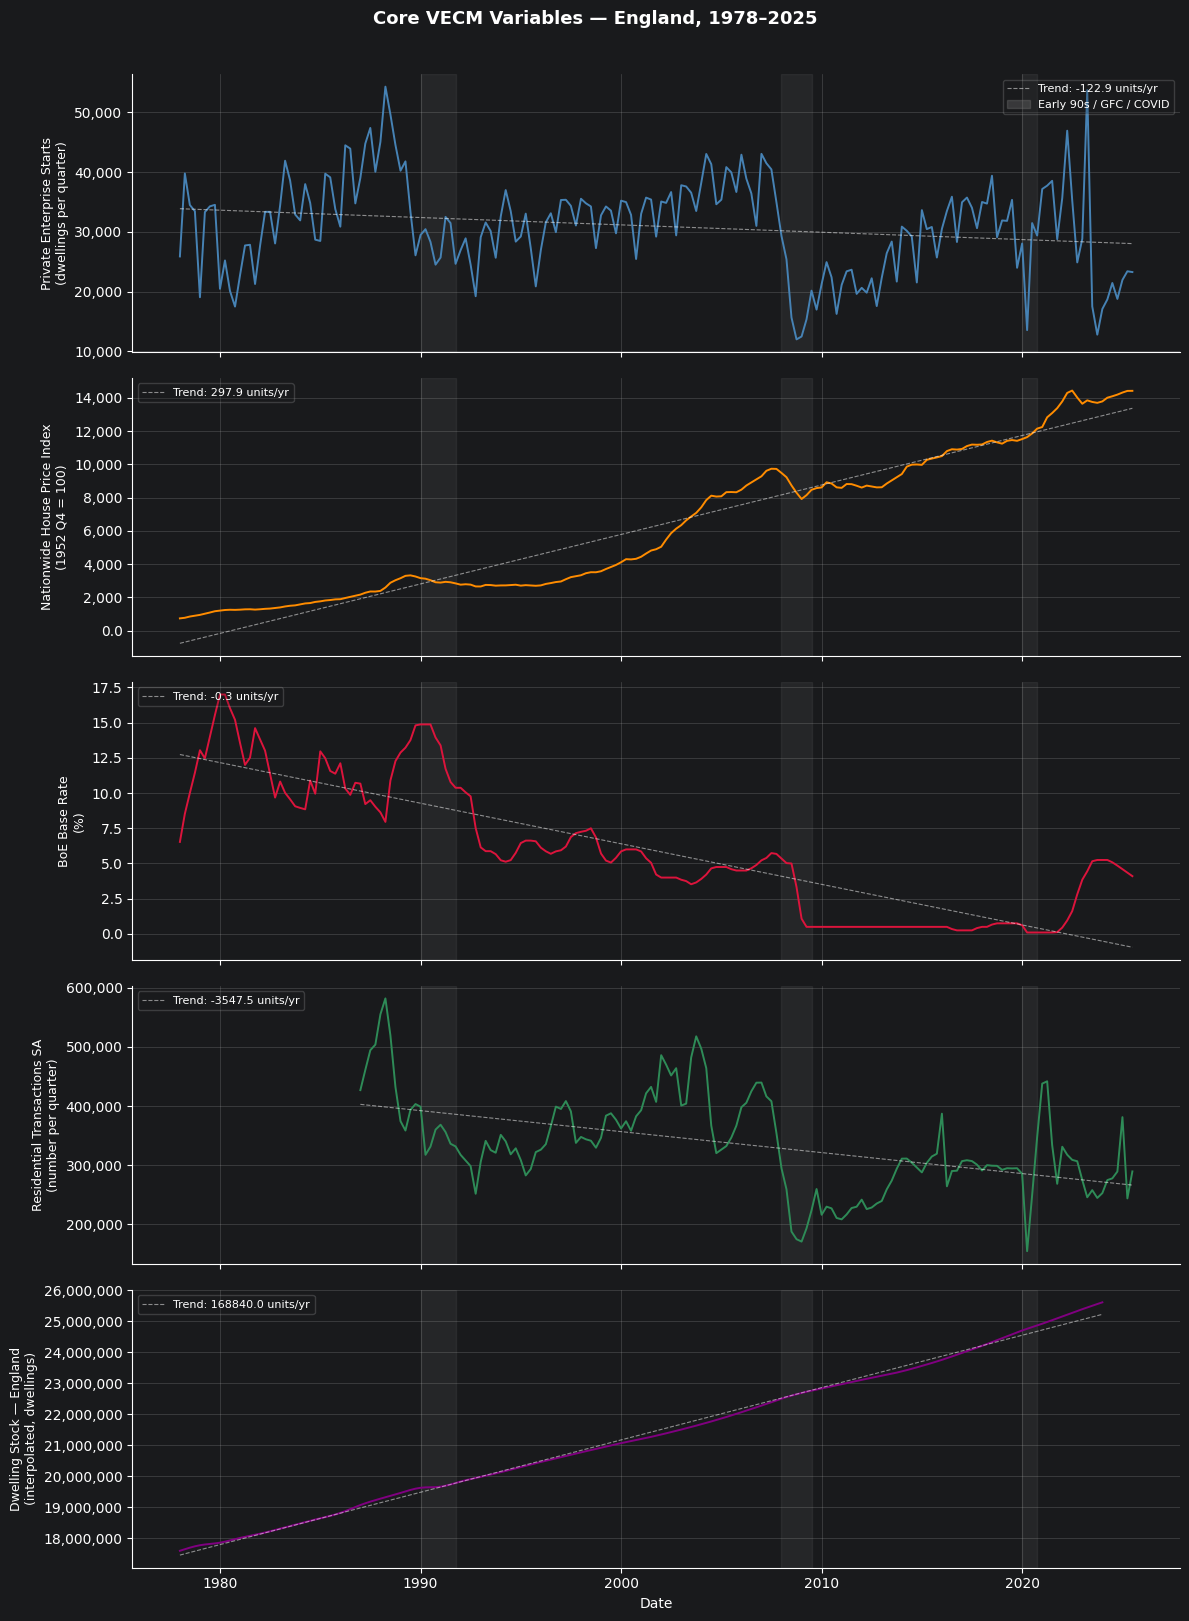

Saved: 01_vecm_series_panel.png


In [17]:
series = [
    ("starts_private",    "Private Enterprise Starts\n(dwellings per quarter)",  "steelblue"),
    ("hpi_index",         "Nationwide House Price Index\n(1952 Q4 = 100)",        "darkorange"),
    ("base_rate",         "BoE Base Rate\n(%)",                                   "crimson"),
    ("transactions_sa",   "Residential Transactions SA\n(number per quarter)",    "seagreen"),
    ("housing_stock_eng", "Dwelling Stock — England\n(interpolated, dwellings)",  "purple"),
]

shading = [
    ("1990-01-01", "1991-10-01"),
    ("2008-01-01", "2009-07-01"),
    ("2020-01-01", "2020-10-01"),
]

def add_shading(ax):
    for start, end in shading:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color="grey", zorder=0)

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
fig.suptitle("Core VECM Variables — England, 1978–2025",
             fontsize=13, fontweight="bold", y=1.01)

for ax, (col, ylabel, color) in zip(axes, series):
    s = master[["date", col]].dropna()
    ax.plot(s["date"], s[col], color=color, linewidth=1.4)
    add_shading(ax)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:,.0f}" if abs(x) >= 1000 else f"{x:.1f}")
    )
    t = np.arange(len(s))
    slope, intercept = np.polyfit(t, s[col], 1)
    trend = intercept + slope * t
    ax.plot(s["date"], trend, color="white", linewidth=0.8,
            linestyle="--", alpha=0.5, label=f"Trend: {slope*4:.1f} units/yr")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.2)

grey_patch = mpatches.Patch(color="grey", alpha=0.3, label="Early 90s / GFC / COVID")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles + [grey_patch],
               loc="upper right", fontsize=8, framealpha=0.2)

axes[-1].set_xlabel("Date")
fig.tight_layout()

import os
os.makedirs("../data/outputs", exist_ok=True)
plt.savefig("../data/outputs/01_vecm_series_panel.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01_vecm_series_panel.png")

# Plotting Log Level Variables

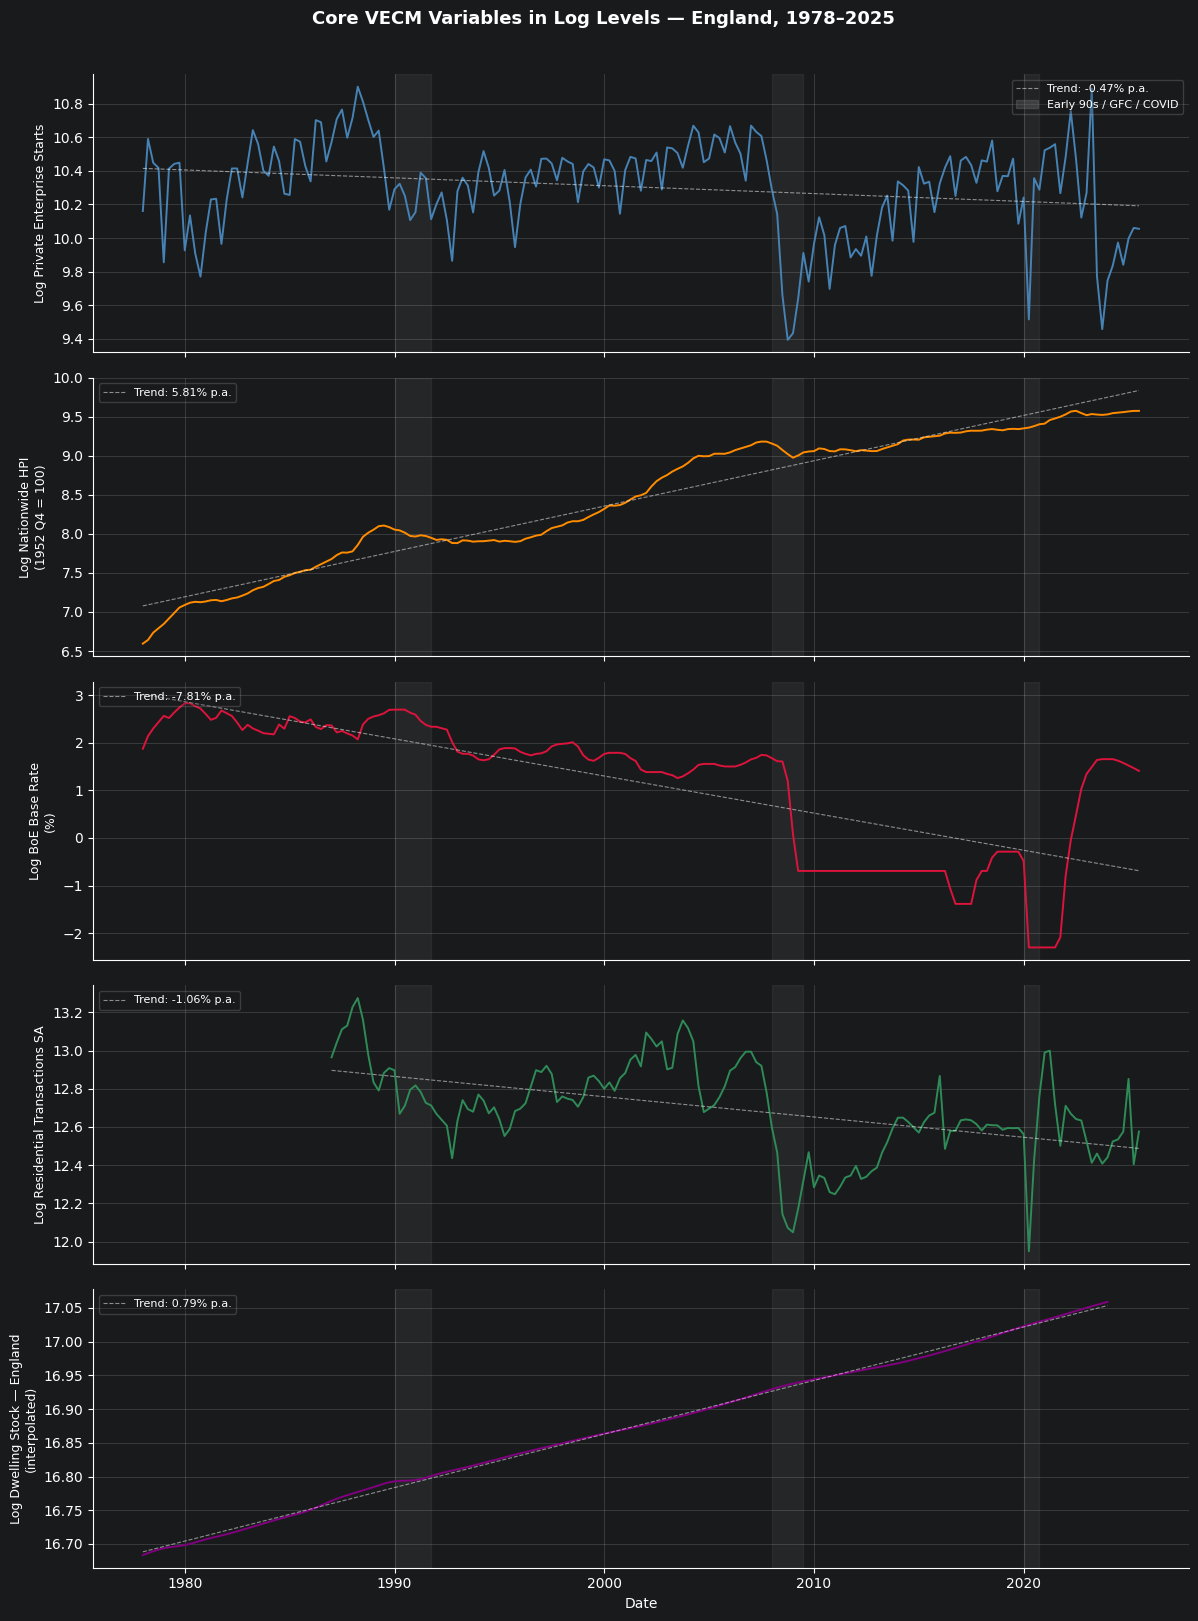

Saved: 02_log_levels_panel.png


In [18]:
# Log transform — drop nulls per series so gaps don't break the plot
log_series = [
    ("starts_private",    "Log Private Enterprise Starts",               "steelblue"),
    ("hpi_index",         "Log Nationwide HPI\n(1952 Q4 = 100)",         "darkorange"),
    ("base_rate",         "Log BoE Base Rate\n(%)",                      "crimson"),
    ("transactions_sa",   "Log Residential Transactions SA",             "seagreen"),
    ("housing_stock_eng", "Log Dwelling Stock — England\n(interpolated)","purple"),
]

shading = [
    ("1990-01-01", "1991-10-01"),
    ("2008-01-01", "2009-07-01"),
    ("2020-01-01", "2020-10-01"),
]

def add_shading(ax):
    for start, end in shading:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color="grey", zorder=0)

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
fig.suptitle("Core VECM Variables in Log Levels — England, 1978–2025",
             fontsize=13, fontweight="bold", y=1.01)

for ax, (col, ylabel, color) in zip(axes, log_series):
    s = master[["date", col]].dropna()
    log_vals = np.log(s[col])

    ax.plot(s["date"], log_vals, color=color, linewidth=1.4)
    add_shading(ax)
    ax.set_ylabel(ylabel, fontsize=9)

    # Annotate approximate slope (linear trend in logs = growth rate)
    t = np.arange(len(s))
    slope, intercept = np.polyfit(t, log_vals, 1)
    trend = intercept + slope * t
    ax.plot(s["date"], trend, color="white", linewidth=0.8,
            linestyle="--", alpha=0.5, label=f"Trend: {slope*400:.2f}% p.a.")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.2)

# Remove the legend block after the loop and replace with just this:
grey_patch = mpatches.Patch(color="grey", alpha=0.3, label="Early 90s / GFC / COVID")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles + [grey_patch],
               loc="upper right", fontsize=8, framealpha=0.2)

axes[-1].set_xlabel("Date")
fig.tight_layout()

import os
os.makedirs("../data/outputs", exist_ok=True)
plt.savefig("../data/outputs/02_log_levels_panel.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 02_log_levels_panel.png")

# Stationarity Testing

In [21]:
# Variables tested in log levels; base_rate tested in levels
log_vars = ["starts_private", "hpi_index", "transactions_sa", "housing_stock_eng"]
level_vars = ["base_rate"]

# Build working dataframe in logs + levels, dropping rows with any null
adf_df = master[["date"] + log_vars + level_vars].dropna().copy()
for col in log_vars:
    adf_df[f"log_{col}"] = np.log(adf_df[col])

In [22]:
def run_adf(series, label, trend="ct"):
    result = adfuller(series.dropna(), regression=trend, autolag="AIC")
    return {
        "Variable": label,
        "Lags": result[2],
        "ADF Stat": round(result[0], 3),
        "p-value": round(result[1], 3),
        "1%": round(result[4]["1%"], 3),
        "5%": round(result[4]["5%"], 3),
        "10%": round(result[4]["10%"], 3),
        "Reject H0 (5%)": "Yes" if result[1] < 0.05 else "No",
    }

rows = []
for col in log_vars:
    rows.append(run_adf(adf_df[f"log_{col}"], f"log({col})", trend="ct"))
rows.append(run_adf(adf_df["base_rate"], "base_rate", trend="ct"))

levels_results = pd.DataFrame(rows)
print("ADF Tests — Log Levels (trend='ct': constant + trend)\n")
print(levels_results.to_string(index=False))

ADF Tests — Log Levels (trend='ct': constant + trend)

              Variable  Lags  ADF Stat  p-value     1%     5%    10% Reject H0 (5%)
   log(starts_private)     4    -3.841    0.015 -4.023 -3.441 -3.145            Yes
        log(hpi_index)    13    -2.152    0.517 -4.027 -3.444 -3.146             No
  log(transactions_sa)     0    -3.407    0.050 -4.021 -3.441 -3.145             No
log(housing_stock_eng)    14    -3.608    0.029 -4.028 -3.444 -3.147            Yes
             base_rate     2    -2.132    0.528 -4.022 -3.441 -3.145             No


# NOTE
Housing stock was interpolated which is why it is showing stationary properties

# Zivot-Andrews Test
Needs fixing

In [32]:
from statsmodels.tsa.stattools import zivot_andrews

# Columns as they actually exist in adf_df
za_cols = {
    "log_starts_private":    adf_df["log_starts_private"],
    "log_hpi_index":         adf_df["log_hpi_index"],
    "log_transactions_sa":   adf_df["log_transactions_sa"],
    "log_housing_stock_eng": adf_df["log_housing_stock_eng"],
    "base_rate":             adf_df["base_rate"],
}

za_results = {}
for name, series in za_cols.items():
    series = series.dropna()

    za_stat, pval, cvs, baselag, breakpoint = zivot_andrews(
        series,
        trim=0.15,
        regression="ct"
    )

    break_date = series.index[breakpoint]

    za_results[name] = {
        "ZA Stat":       round(za_stat, 3),
        "p-value":       round(pval, 3),
        "Break date":    break_date,
        "5% CV":         round(cvs["5%"], 3),
        "Reject H0 (5%)": "Yes" if za_stat < cvs["5%"] else "No"
    }

za_df = pd.DataFrame(za_results).T
print("Zivot-Andrews Structural Break Tests\n")
print(za_df.to_string())

Zivot-Andrews Structural Break Tests

                      ZA Stat p-value Break date  5% CV Reject H0 (5%)
log_starts_private     -5.592   0.009        119 -5.073            Yes
log_hpi_index          -4.891   0.085         95 -5.073             No
log_transactions_sa    -4.944   0.073        118 -5.073             No
log_housing_stock_eng  -6.046   0.002        133 -5.073            Yes
base_rate              -3.704   0.696        122 -5.073             No


# Converting break dates

In [34]:
base_index = adf_df[["date", "log_starts_private"]].dropna().reset_index(drop=True)

break_obs = {
    "log_starts_private":    119,
    "log_hpi_index":          95,
    "log_transactions_sa":   118,
    "log_housing_stock_eng": 133,
    "base_rate":             122,
}

print("Break date conversion:")
for name, obs in break_obs.items():
    date = base_index.loc[obs, "date"]
    print(f"  {name:<30} obs {obs:>3}  →  {date.date()}")

Break date conversion:
  log_starts_private             obs 119  →  2016-10-01
  log_hpi_index                  obs  95  →  2010-10-01
  log_transactions_sa            obs 118  →  2016-07-01
  log_housing_stock_eng          obs 133  →  2020-04-01
  base_rate                      obs 122  →  2017-07-01


In [24]:
rows_diff = []
for col in log_vars:
    diff_series = adf_df[f"log_{col}"].diff().dropna()
    rows_diff.append(run_adf(diff_series, f"Δlog({col})", trend="c"))

diff_br = adf_df["base_rate"].diff().dropna()
rows_diff.append(run_adf(diff_br, "Δbase_rate", trend="c"))

diff_results = pd.DataFrame(rows_diff)
print("ADF Tests — First Differences (trend='c': constant only)\n")
print(diff_results.to_string(index=False))

ADF Tests — First Differences (trend='c': constant only)

               Variable  Lags  ADF Stat  p-value     1%     5%    10% Reject H0 (5%)
   Δlog(starts_private)     6    -5.922    0.000 -3.478 -2.882 -2.578            Yes
        Δlog(hpi_index)     8    -3.491    0.008 -3.478 -2.883 -2.578            Yes
  Δlog(transactions_sa)     3    -8.252    0.000 -3.477 -2.882 -2.578            Yes
Δlog(housing_stock_eng)    14    -2.881    0.048 -3.481 -2.884 -2.578            Yes
             Δbase_rate     1    -5.917    0.000 -3.476 -2.882 -2.577            Yes


# Cointegration Testing

In [25]:
adf_df[["date"] + [f"log_{col}" for col in log_vars] + ["base_rate"]].dropna().agg({"date": ["min", "max", "count"]})

,date
min,1987-01-01 00:00:00
max,2024-01-01 00:00:00
count,149


# Fitting VAR

In [28]:
# Build the system matrix — same order as Michalis: starts, hpi, transactions, stock, rate
vecm_vars = ["log_starts_private", "log_hpi_index", "log_transactions_sa",
             "log_housing_stock_eng", "base_rate"]

vecm_df = adf_df[["date"] + [f"log_{c}" if c != "base_rate" else c
                              for c in ["starts_private","hpi_index",
                                        "transactions_sa","housing_stock_eng","base_rate"]]].dropna()

# Rename for clarity
vecm_df.columns = ["date"] + vecm_vars
vecm_df = vecm_df.set_index("date")

# Fit VAR in levels to get lag order criteria
var_model = VAR(vecm_df)
lag_results = var_model.select_order(maxlags=8)
print(lag_results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -13.40      -13.30   1.516e-06      -13.36
1      -33.41      -32.79   3.085e-15      -33.16
2      -36.23      -35.08   1.841e-16      -35.77
3      -37.60      -35.93   4.697e-17      -36.92
4      -38.44     -36.24*   2.045e-17     -37.55*
5      -38.51      -35.80   1.917e-17      -37.41
6      -38.63      -35.39  1.727e-17*      -37.32
7      -38.62      -34.85   1.798e-17      -37.09
8     -38.65*      -34.37   1.782e-17      -36.91
-------------------------------------------------


/home/adrym/projects/dissertation_housing_supply/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


# Johansen Trace Test

In [29]:
# det_order=0: constant restricted to cointegrating space (Michalis spec, Case 3)
# Run for lag orders suggested by AIC and BIC — compare both
for k_ar in [lag_results.aic, lag_results.bic]:
    print(f"\n{'='*60}")
    print(f"Johansen Test — k_ar_diff = {k_ar} (lags in differences)")
    print(f"{'='*60}")

    jres = coint_johansen(vecm_df, det_order=0, k_ar_diff=k_ar)

    # Trace test
    print("\nTrace Test:")
    print(f"{'H0: r<=':>10} {'Stat':>10} {'10%':>8} {'5%':>8} {'1%':>8} {'Reject 5%':>10}")
    for i in range(len(jres.lr1)):
        stat = jres.lr1[i]
        cvs  = jres.cvt[i]   # [10%, 5%, 1%]
        rej  = "Yes" if stat > cvs[1] else "No"
        print(f"{'r<='+str(i):>10} {stat:>10.3f} {cvs[0]:>8.3f} {cvs[1]:>8.3f} {cvs[2]:>8.3f} {rej:>10}")

    # Max eigenvalue test
    print("\nMax Eigenvalue Test:")
    print(f"{'H0: r<=':>10} {'Stat':>10} {'10%':>8} {'5%':>8} {'1%':>8} {'Reject 5%':>10}")
    for i in range(len(jres.lr2)):
        stat = jres.lr2[i]
        cvs  = jres.cvm[i]
        rej  = "Yes" if stat > cvs[1] else "No"
        print(f"{'r<='+str(i):>10} {stat:>10.3f} {cvs[0]:>8.3f} {cvs[1]:>8.3f} {cvs[2]:>8.3f} {rej:>10}")


Johansen Test — k_ar_diff = 8 (lags in differences)

Trace Test:
   H0: r<=       Stat      10%       5%       1%  Reject 5%
      r<=0    120.770   65.820   69.819   77.820        Yes
      r<=1     58.218   44.493   47.855   54.681        Yes
      r<=2     24.359   27.067   29.796   35.463         No
      r<=3      3.062   13.429   15.494   19.935         No
      r<=4      0.110    2.705    3.841    6.635         No

Max Eigenvalue Test:
   H0: r<=       Stat      10%       5%       1%  Reject 5%
      r<=0     62.551   31.238   33.878   39.369        Yes
      r<=1     33.860   25.124   27.586   32.717        Yes
      r<=2     21.297   18.893   21.131   25.865        Yes
      r<=3      2.952   12.297   14.264   18.520         No
      r<=4      0.110    2.705    3.841    6.635         No

Johansen Test — k_ar_diff = 4 (lags in differences)

Trace Test:
   H0: r<=       Stat      10%       5%       1%  Reject 5%
      r<=0     91.804   65.820   69.819   77.820        Yes
      